In [1]:
# ============================================================
# 1. INSTALL / IMPORT LIBRARIES
# ============================================================
!pip -q install -U scikit-learn seaborn

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 53.1 MB/s eta 0:00:00
TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Dataset Preparation

The manual specifies CIFAR-10 with 50,000 training images, 10,000 test images, 10 classes, and image size 32×32×3. Pixel values are normalized to [0,1] for the dataset visualization/base representation.

For VGG16, images are resized to **96×96×3** before being passed to the pretrained network. VGG16's ImageNet preprocessing is then applied inside the model pipeline.


In [2]:
# ============================================================
# 2. LOAD AND PREPARE CIFAR-10
# ============================================================
class_names = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize to [0, 1] as required by the manual
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

y_train = y_train.flatten()
y_test = y_test.flatten()

print("Training images :", x_train.shape)
print("Training labels :", y_train.shape)
print("Testing images  :", x_test.shape)
print("Testing labels  :", y_test.shape)
print("Number of classes:", len(class_names))


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1623s 10us/step
Training images : (50000, 32, 32, 3)
Training labels : (50000,)
Testing images  : (10000, 32, 32, 3)
Testing labels  : (10000,)
Number of classes: 10


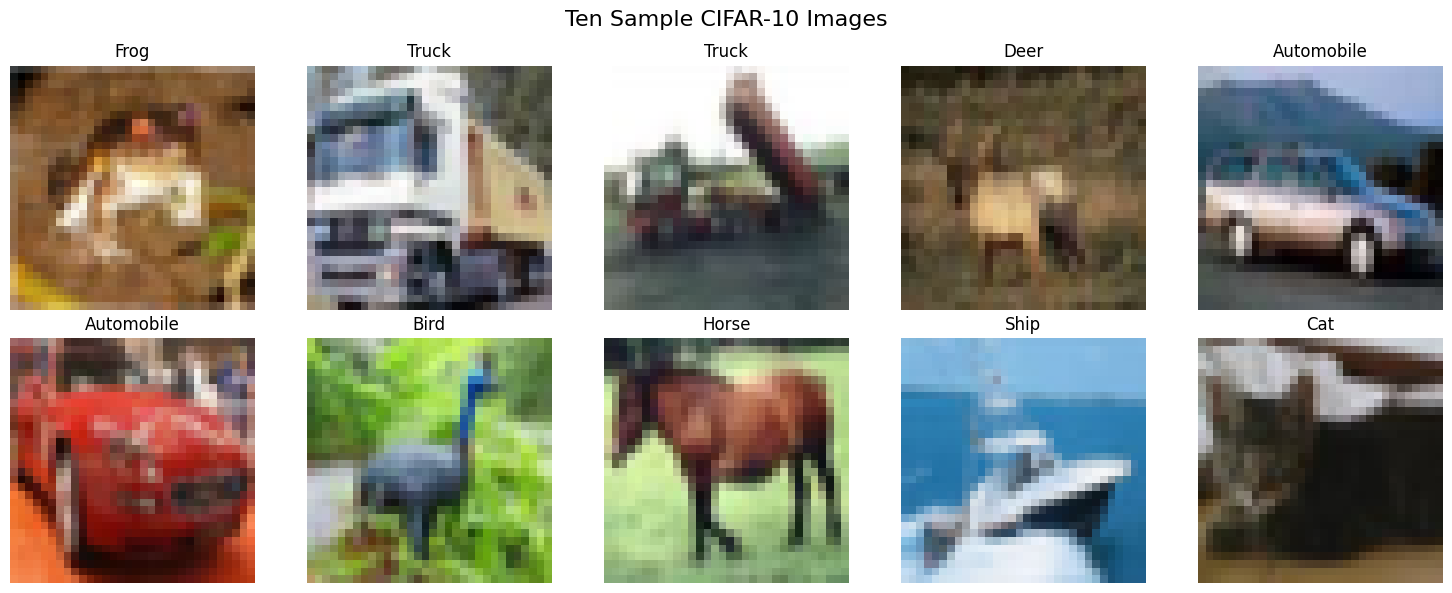

In [3]:
# ============================================================
# 3. DISPLAY TEN SAMPLE CIFAR-10 IMAGES
# ============================================================
plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.suptitle("Ten Sample CIFAR-10 Images", fontsize=16)
plt.tight_layout()
plt.show()


## 3. Train/Validation Split

The original 50,000 training images are split into training and validation sets. The test set remains untouched until final evaluation.


In [4]:
# ============================================================
# 4. TRAIN / VALIDATION SPLIT
# ============================================================
VAL_SIZE = 5000

x_val = x_train[-VAL_SIZE:]
y_val = y_train[-VAL_SIZE:]

x_train_main = x_train[:-VAL_SIZE]
y_train_main = y_train[:-VAL_SIZE]

print("Training set  :", x_train_main.shape)
print("Validation set:", x_val.shape)
print("Test set      :", x_test.shape)


Training set  : (45000, 32, 32, 3)
Validation set: (5000, 32, 32, 3)
Test set      : (10000, 32, 32, 3)


## 4. VGG16 Transfer Learning

Following the lab manual:
1. Load ImageNet pretrained weights.
2. Remove the original classifier (`include_top=False`).
3. Freeze the convolutional base.
4. Add Global Average Pooling.
5. Add Dense + ReLU.
6. Add Dense + Softmax for 10 CIFAR-10 classes.


In [5]:
# ============================================================
# 5. VGG16 TRANSFER LEARNING MODEL
# ============================================================
IMG_SIZE = 96
NUM_CLASSES = 10
BATCH_SIZE = 32
INITIAL_EPOCHS = 3
FINE_TUNE_EPOCHS = 2

def build_vgg16_transfer_model(dense_units=256, learning_rate=0.001):
    base_model = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # Freeze convolutional base
    base_model.trainable = False

    inputs = keras.Input(shape=(32, 32, 3), name="cifar10_input")

    # Resize CIFAR-10 32x32 -> 96x96
    x = layers.Resizing(IMG_SIZE, IMG_SIZE)(inputs)

    # VGG16 ImageNet preprocessing
    x = layers.Lambda(preprocess_input, name="vgg16_preprocess")(x * 255.0)

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
    x = layers.Dense(dense_units, activation="relu", name="dense_relu")(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="softmax_output")(x)

    model = keras.Model(inputs, outputs, name="VGG16_Transfer_Learning")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model, base_model

model, base_model = build_vgg16_transfer_model()

model.summary()
print("\nTrainable parameters:", model.count_params())


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cifar10_input (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16_preprocess (Lambda)       │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_relu (Dense)              │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_output (Dense)          │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)


Trainable parameters: 14848586


In [6]:
# ============================================================
# 6. DATA PIPELINES
# ============================================================
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((x_train_main, y_train_main))
val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))

train_ds = (
    train_ds
    .shuffle(10000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("Datasets ready.")


Datasets ready.


In [7]:
# ============================================================
# 7. TRAIN THE FROZEN VGG16 MODEL
# ============================================================
start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    verbose=1
)

initial_training_time = time.time() - start_time

print(f"\nInitial training time: {initial_training_time/60:.2f} minutes")


Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.7743 - loss: 0.7663 - val_accuracy: 0.8092 - val_loss: 0.5531
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 67s 47ms/step - accuracy: 0.8456 - loss: 0.4465 - val_accuracy: 0.8192 - val_loss: 0.5235
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.8671 - loss: 0.3790 - val_accuracy: 0.8260 - val_loss: 0.5475
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.8904 - loss: 0.3094 - val_accuracy: 0.8268 - val_loss: 0.5540
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.9090 - loss: 0.2548 - val_accuracy: 0.8254 - val_loss: 0.6159
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.9253 - loss: 0.2078 - val_accuracy: 0.8250 - val_loss: 0.6598
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.9394 - loss: 0.1716 - val_accuracy: 0.8282 - val_loss: 0.6955
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.9504 -

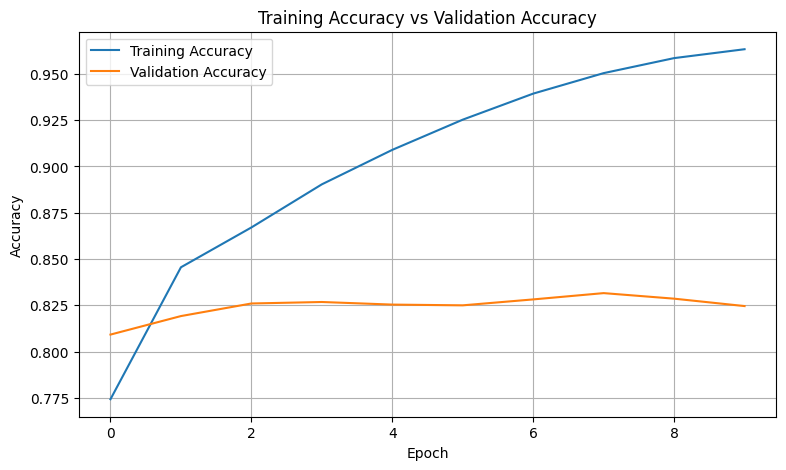

Inference: The curves show how classification accuracy changes during training.
A small train-validation gap generally indicates better generalization.


In [8]:
# ============================================================
# 8. TRAINING ACCURACY / VALIDATION ACCURACY
# ============================================================
plt.figure(figsize=(9, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

print("Inference: The curves show how classification accuracy changes during training.")
print("A small train-validation gap generally indicates better generalization.")


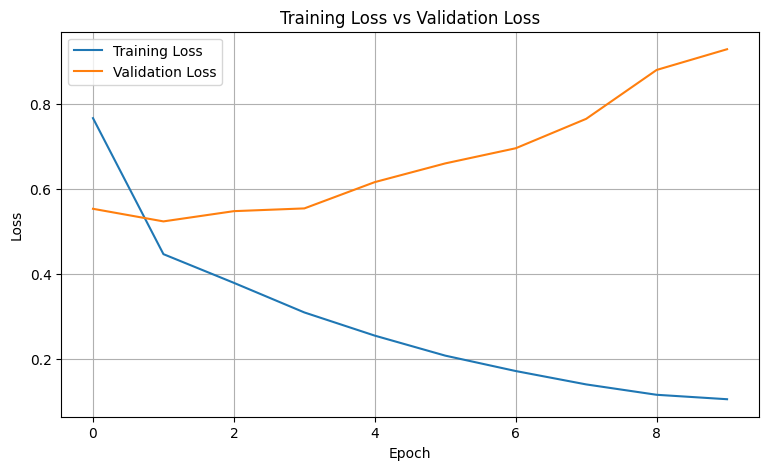

Inference: Training loss should generally decrease as the classifier learns.
Validation loss helps identify underfitting or overfitting.


In [9]:
# ============================================================
# 9. TRAINING LOSS / VALIDATION LOSS
# ============================================================
plt.figure(figsize=(9, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

print("Inference: Training loss should generally decrease as the classifier learns.")
print("Validation loss helps identify underfitting or overfitting.")


## 6. Evaluation Before Fine-Tuning


In [10]:
# ============================================================
# 10. EVALUATE BEFORE FINE-TUNING
# ============================================================
def get_predictions(model, dataset):
    probabilities = model.predict(dataset, verbose=0)
    predictions = np.argmax(probabilities, axis=1)
    return predictions

y_pred_before = get_predictions(model, test_ds)

test_accuracy_before = accuracy_score(y_test, y_pred_before)
precision_before = precision_score(y_test, y_pred_before, average="weighted", zero_division=0)
recall_before = recall_score(y_test, y_pred_before, average="weighted", zero_division=0)
f1_before = f1_score(y_test, y_pred_before, average="weighted", zero_division=0)

print(f"Testing Accuracy : {test_accuracy_before:.4f}")
print(f"Precision        : {precision_before:.4f}")
print(f"Recall           : {recall_before:.4f}")
print(f"F1-score         : {f1_before:.4f}")


Testing Accuracy : 0.8184
Precision        : 0.8191
Recall           : 0.8184
F1-score         : 0.8184


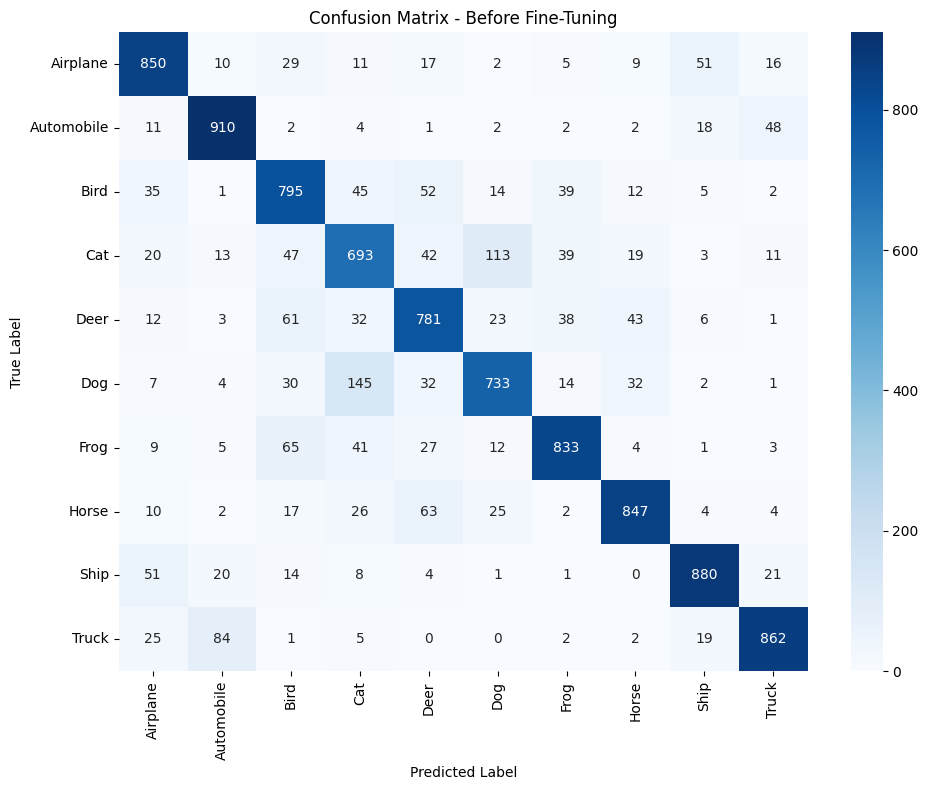

Inference: The diagonal contains correctly classified samples.
Off-diagonal values indicate which classes are being confused.


In [11]:
# ============================================================
# 11. CONFUSION MATRIX BEFORE FINE-TUNING
# ============================================================
cm_before = confusion_matrix(y_test, y_pred_before)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_before,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Before Fine-Tuning")
plt.tight_layout()
plt.show()

print("Inference: The diagonal contains correctly classified samples.")
print("Off-diagonal values indicate which classes are being confused.")


In [12]:
# ============================================================
# 12. CLASSIFICATION REPORT BEFORE FINE-TUNING
# ============================================================
print("Classification Report - Before Fine-Tuning")
print(classification_report(
    y_test,
    y_pred_before,
    target_names=class_names,
    digits=4,
    zero_division=0
))


Classification Report - Before Fine-Tuning
              precision    recall  f1-score   support

    Airplane     0.8252    0.8500    0.8374      1000
  Automobile     0.8650    0.9100    0.8869      1000
        Bird     0.7493    0.7950    0.7715      1000
         Cat     0.6861    0.6930    0.6896      1000
        Deer     0.7664    0.7810    0.7737      1000
         Dog     0.7924    0.7330    0.7616      1000
        Frog     0.8544    0.8330    0.8435      1000
       Horse     0.8732    0.8470    0.8599      1000
        Ship     0.8898    0.8800    0.8849      1000
       Truck     0.8896    0.8620    0.8756      1000

    accuracy                         0.8184     10000
   macro avg     0.8191    0.8184    0.8184     10000
weighted avg     0.8191    0.8184    0.8184     10000



## 7. Fine-Tuning

The manual requires:
1. Unfreeze the last convolution block.
2. Train for another 5–10 epochs.
3. Compare accuracy before and after fine-tuning.

For VGG16, the last convolutional block is **block5**. Only this block is unfrozen; the earlier feature-extraction layers remain frozen.


In [13]:
# ============================================================
# 13. UNFREEZE ONLY VGG16 BLOCK 5
# ============================================================
base_model.trainable = True

for layer in base_model.layers:
    layer.trainable = layer.name.startswith("block5")

print("Trainable VGG16 layers:")
for layer in base_model.layers:
    if layer.trainable:
        print(layer.name)

# Recompile with a smaller LR for stable fine-tuning.
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nTrainable parameters after fine-tuning setup:",
      sum(np.prod(v.shape) for v in model.trainable_weights))


Trainable VGG16 layers:
block5_conv1
block5_conv2
block5_conv3
block5_pool

Trainable parameters after fine-tuning setup: 7213322


In [14]:
# ============================================================
# 14. FINE-TUNE FOR 5 MORE EPOCHS
# ============================================================
fine_start = time.time()

fine_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    verbose=1
)

fine_tuning_time = time.time() - fine_start
total_training_time = initial_training_time + fine_tuning_time

print(f"\nFine-tuning time: {fine_tuning_time/60:.2f} minutes")
print(f"Total training time: {total_training_time/60:.2f} minutes")


Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 97s 66ms/step - accuracy: 0.8500 - loss: 0.4866 - val_accuracy: 0.8750 - val_loss: 0.3947
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 89s 63ms/step - accuracy: 0.9174 - loss: 0.2525 - val_accuracy: 0.8818 - val_loss: 0.4046
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 88s 63ms/step - accuracy: 0.9410 - loss: 0.1764 - val_accuracy: 0.8956 - val_loss: 0.3700
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 89s 63ms/step - accuracy: 0.9566 - loss: 0.1285 - val_accuracy: 0.8968 - val_loss: 0.3781
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 88s 63ms/step - accuracy: 0.9664 - loss: 0.1008 - val_accuracy: 0.9140 - val_loss: 0.3665

Fine-tuning time: 7.52 minutes
Total training time: 18.71 minutes


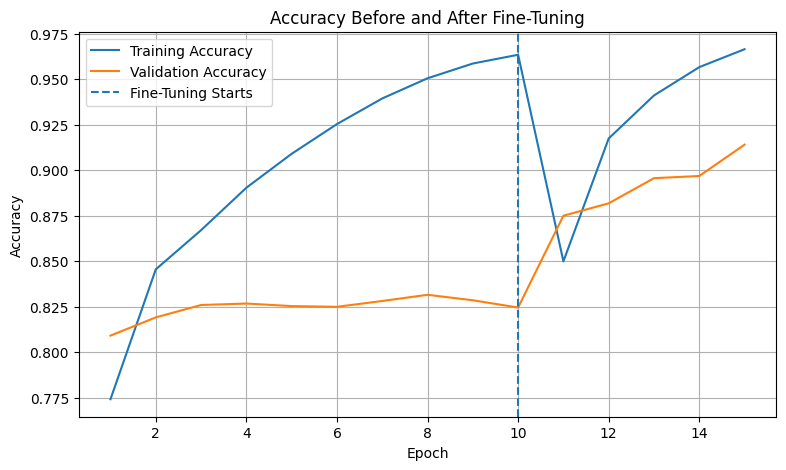

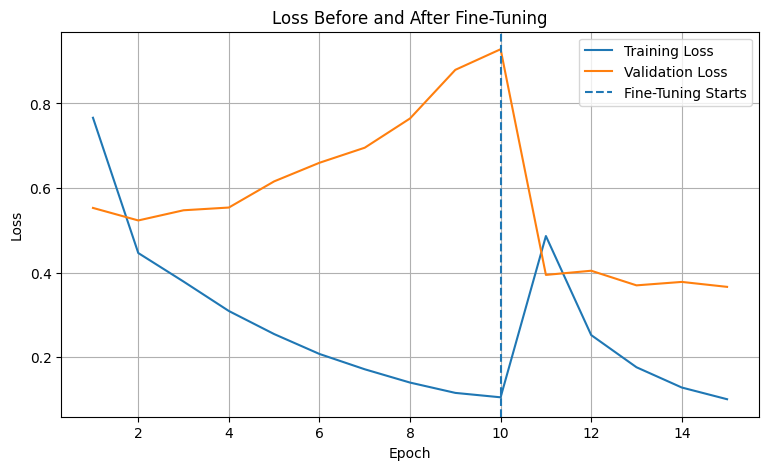

In [15]:
# ============================================================
# 15. COMBINE CURVES BEFORE AND AFTER FINE-TUNING
# ============================================================
train_acc = history.history["accuracy"] + fine_history.history["accuracy"]
val_acc = history.history["val_accuracy"] + fine_history.history["val_accuracy"]

train_loss = history.history["loss"] + fine_history.history["loss"]
val_loss = history.history["val_loss"] + fine_history.history["val_loss"]

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs, train_acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.axvline(INITIAL_EPOCHS, linestyle="--", label="Fine-Tuning Starts")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Before and After Fine-Tuning")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.axvline(INITIAL_EPOCHS, linestyle="--", label="Fine-Tuning Starts")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Before and After Fine-Tuning")
plt.legend()
plt.grid(True)
plt.show()


In [16]:
# ============================================================
# 16. FINAL EVALUATION AFTER FINE-TUNING
# ============================================================
y_pred_after = get_predictions(model, test_ds)

test_accuracy_after = accuracy_score(y_test, y_pred_after)
precision_after = precision_score(y_test, y_pred_after, average="weighted", zero_division=0)
recall_after = recall_score(y_test, y_pred_after, average="weighted", zero_division=0)
f1_after = f1_score(y_test, y_pred_after, average="weighted", zero_division=0)

print(f"Testing Accuracy : {test_accuracy_after:.4f}")
print(f"Precision        : {precision_after:.4f}")
print(f"Recall           : {recall_after:.4f}")
print(f"F1-score         : {f1_after:.4f}")
print(f"Training Time    : {total_training_time/60:.2f} minutes")
print(f"Total Parameters : {model.count_params():,}")


Testing Accuracy : 0.9036
Precision        : 0.9059
Recall           : 0.9036
F1-score         : 0.9038
Training Time    : 18.71 minutes
Total Parameters : 14,848,586


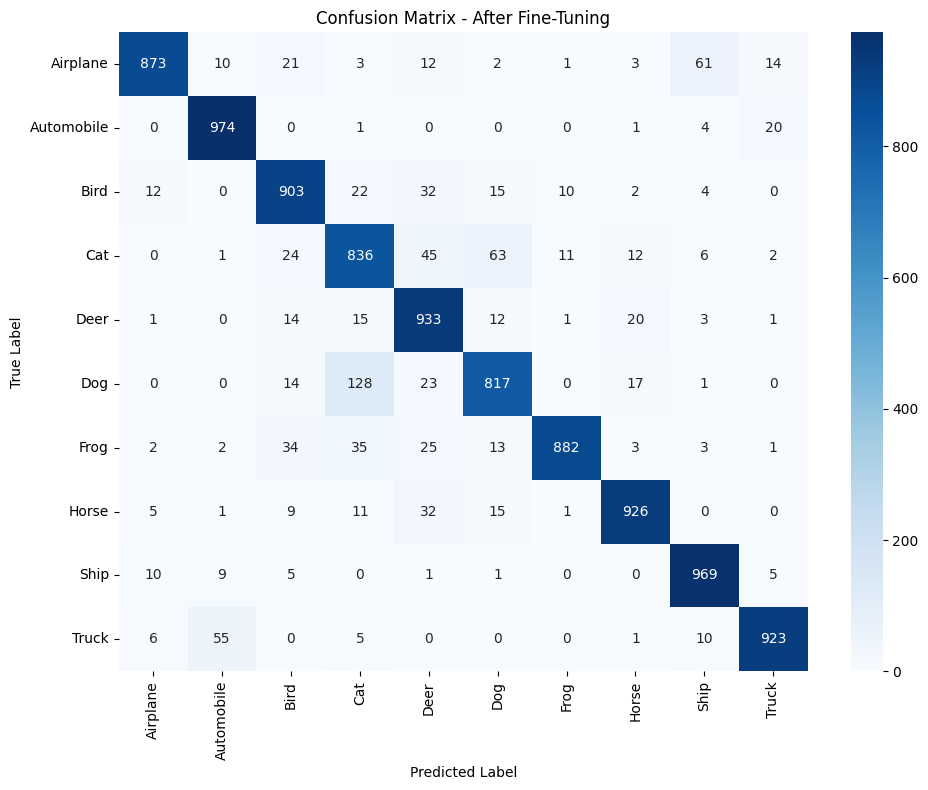

Inference: Stronger diagonal values indicate correct classification.
The off-diagonal cells show remaining class-level confusion.


In [17]:
# ============================================================
# 17. CONFUSION MATRIX AFTER FINE-TUNING
# ============================================================
cm_after = confusion_matrix(y_test, y_pred_after)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_after,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - After Fine-Tuning")
plt.tight_layout()
plt.show()

print("Inference: Stronger diagonal values indicate correct classification.")
print("The off-diagonal cells show remaining class-level confusion.")


In [18]:
# ============================================================
# 18. FINAL CLASSIFICATION REPORT
# ============================================================
print("Classification Report - After Fine-Tuning")
print(classification_report(
    y_test,
    y_pred_after,
    target_names=class_names,
    digits=4,
    zero_division=0
))


Classification Report - After Fine-Tuning
              precision    recall  f1-score   support

    Airplane     0.9604    0.8730    0.9146      1000
  Automobile     0.9259    0.9740    0.9493      1000
        Bird     0.8818    0.9030    0.8923      1000
         Cat     0.7917    0.8360    0.8132      1000
        Deer     0.8459    0.9330    0.8873      1000
         Dog     0.8710    0.8170    0.8431      1000
        Frog     0.9735    0.8820    0.9255      1000
       Horse     0.9401    0.9260    0.9330      1000
        Ship     0.9133    0.9690    0.9403      1000
       Truck     0.9555    0.9230    0.9390      1000

    accuracy                         0.9036     10000
   macro avg     0.9059    0.9036    0.9038     10000
weighted avg     0.9059    0.9036    0.9038     10000



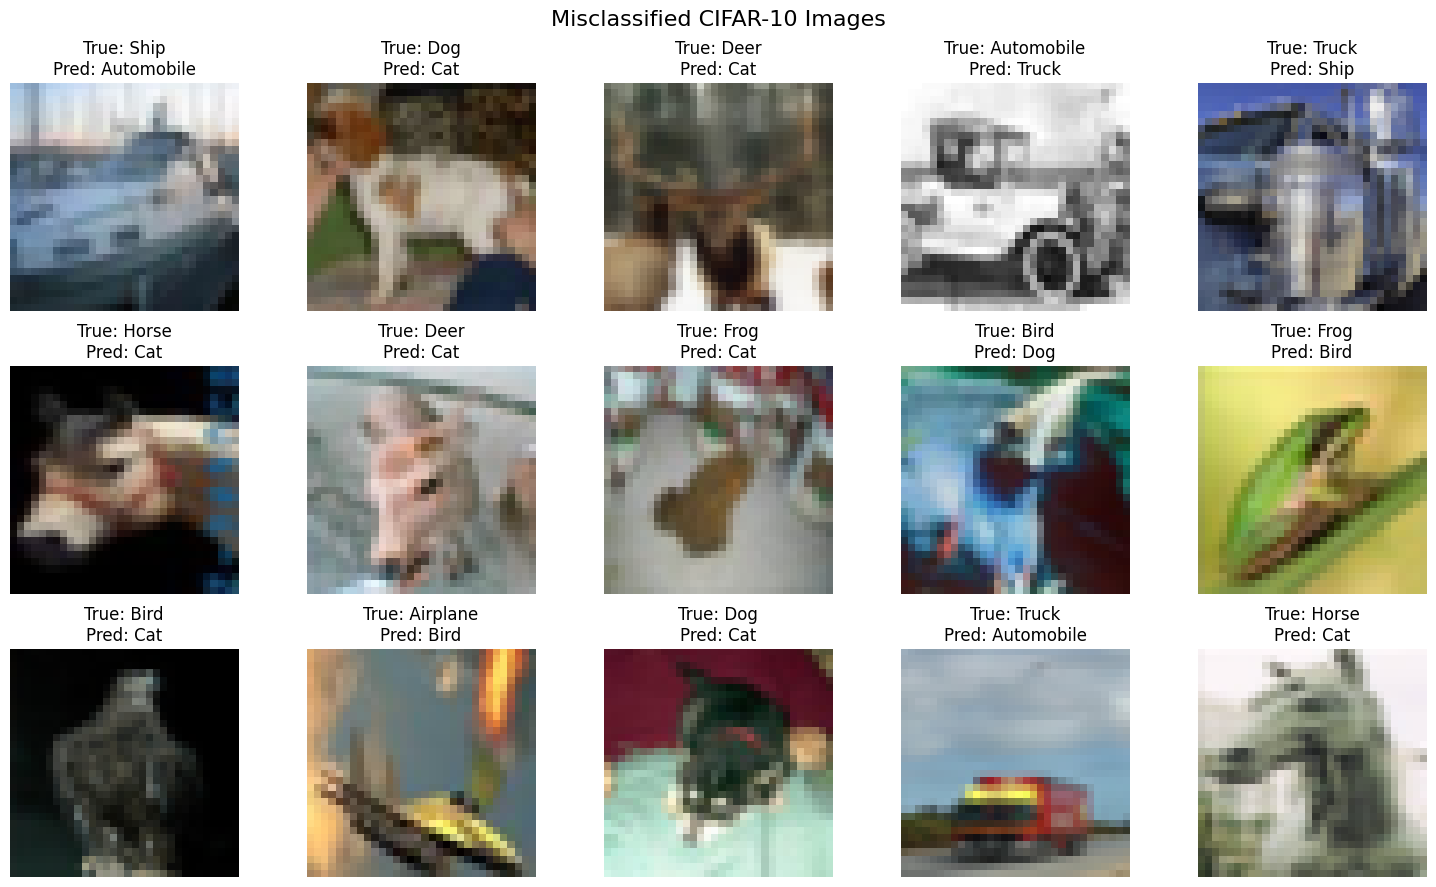

In [19]:
# ============================================================
# 19. OPTIONAL: MISCLASSIFIED IMAGES
# ============================================================
wrong_indices = np.where(y_test != y_pred_after)[0]

plt.figure(figsize=(15, 9))
num_to_show = min(15, len(wrong_indices))

for i in range(num_to_show):
    idx = wrong_indices[i]
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred_after[idx]]}")
    plt.axis("off")

plt.suptitle("Misclassified CIFAR-10 Images", fontsize=16)
plt.tight_layout()
plt.show()


## 8. Performance Metrics Table

This produces the same categories requested in the manual's Results section.


In [20]:
# ============================================================
# 20. PERFORMANCE METRICS TABLE
# ============================================================
# Training accuracy is the last epoch's training accuracy.
final_training_accuracy = train_acc[-1]

performance_table = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Testing Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Training Time (minutes)",
        "Total Parameters"
    ],
    "Value": [
        final_training_accuracy,
        test_accuracy_after,
        precision_after,
        recall_after,
        f1_after,
        total_training_time / 60,
        model.count_params()
    ]
})

display(performance_table)


,Metric,Value
0,Training Accuracy,9.663778e-01
1,Testing Accuracy,9.036000e-01
2,Precision,9.059019e-01
3,Recall,9.036000e-01
4,F1-score,9.037674e-01
5,Training Time (minutes),1.870812e+01
6,Total Parameters,1.484859e+07


## 9. Hyperparameter Study

The manual lists these settings:

| Hyperparameter | Values |
|---|---|
| Learning Rate | 0.001, 0.0001 |
| Batch Size | 16, 32, 64 |
| Epochs | 10, 20 |
| Optimizer | Adam, SGD |
| Dense Units | 128, 256 |
| Frozen Layers | All, Partial |

The function below lets you run representative comparisons. **For the report, run at least 2–4 configurations** if time permits. A full Cartesian product is intentionally not run automatically because it would require many complete training runs.


In [28]:
# ============================================================
# 21. HYPERPARAMETER EXPERIMENT FUNCTION
# ============================================================

def run_hyperparameter_experiment(
    learning_rate=0.001,
    batch_size=32,
    epochs=3,
    optimizer_name="Adam",
    dense_units=256,
    freeze_mode="All"
):

    # --------------------------------------------------------
    # 1. Build a fresh VGG16 model
    # --------------------------------------------------------
    base = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # --------------------------------------------------------
    # 2. Freeze / partially unfreeze VGG16
    # --------------------------------------------------------
    if freeze_mode == "All":
        base.trainable = False

    else:
        # Freeze all layers first
        base.trainable = True

        for layer in base.layers:
            layer.trainable = False

        # Unfreeze only Block 5
        for layer in base.layers:
            if layer.name.startswith("block5"):
                layer.trainable = True

    # --------------------------------------------------------
    # 3. Build classification model
    # --------------------------------------------------------
    inputs = keras.Input(
        shape=(32, 32, 3),
        name="cifar10_input"
    )

    # Resize CIFAR-10 images to VGG16 input size
    x = layers.Resizing(
        IMG_SIZE,
        IMG_SIZE
    )(inputs)

    # Convert pixel values back to [0,255]
    x = layers.Rescaling(
        scale=255.0
    )(x)

    # VGG16 preprocessing
    x = layers.Lambda(
        preprocess_input
    )(x)

    # VGG16 feature extractor
    x = base(
        x,
        training=False
    )

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Dense layer
    x = layers.Dense(
        dense_units,
        activation="relu"
    )(x)

    # 10-class output
    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    # Final model
    m = keras.Model(
        inputs=inputs,
        outputs=outputs
    )

    # --------------------------------------------------------
    # 4. Select optimizer
    # --------------------------------------------------------
    if optimizer_name == "Adam":

        opt = keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    else:

        opt = keras.optimizers.SGD(
            learning_rate=learning_rate,
            momentum=0.9
        )

    # --------------------------------------------------------
    # 5. Compile
    # --------------------------------------------------------
    m.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # --------------------------------------------------------
    # 6. Create datasets with selected batch size
    # --------------------------------------------------------
    tr = (
        tf.data.Dataset
        .from_tensor_slices(
            (x_train_main, y_train_main)
        )
        .shuffle(
            10000,
            seed=SEED
        )
        .batch(batch_size)
        .prefetch(AUTOTUNE)
    )

    va = (
        tf.data.Dataset
        .from_tensor_slices(
            (x_val, y_val)
        )
        .batch(batch_size)
        .prefetch(AUTOTUNE)
    )

    # --------------------------------------------------------
    # 7. Train
    # --------------------------------------------------------
    t0 = time.time()

    h = m.fit(
        tr,
        validation_data=va,
        epochs=epochs,
        verbose=1
    )

    elapsed = time.time() - t0

    # --------------------------------------------------------
    # 8. Test evaluation
    # --------------------------------------------------------
    test_eval_ds = (
    tf.data.Dataset
    .from_tensor_slices((x_test, y_test))
    .batch(batch_size)
    .prefetch(AUTOTUNE)
    )

    test_loss, test_acc = m.evaluate(
    test_eval_ds,
    verbose=0
)

    # --------------------------------------------------------
    # 9. Return results
    # --------------------------------------------------------
    return {
        "Learning Rate": learning_rate,
        "Batch Size": batch_size,
        "Epochs": epochs,
        "Optimizer": optimizer_name,
        "Dense Units": dense_units,
        "Frozen Layers": freeze_mode,
        "Test Accuracy": test_acc,
        "Training Time (min)": elapsed / 60,
        "Parameters": m.count_params()
    }

In [29]:
# ============================================================
# 22. RUN A SMALL, REPORT-FRIENDLY HYPERPARAMETER STUDY
# ============================================================
# You can add/remove configurations here.
# Each row changes one or more settings from the baseline.

configs = [
    # Baseline
    dict(learning_rate=0.001, batch_size=32, epochs=3,
         optimizer_name="Adam", dense_units=256, freeze_mode="All"),

    # Lower learning rate
    dict(learning_rate=0.0001, batch_size=32, epochs=3,
         optimizer_name="Adam", dense_units=256, freeze_mode="All"),

    # Different optimizer
    dict(learning_rate=0.001, batch_size=32, epochs=3,
         optimizer_name="SGD", dense_units=256, freeze_mode="All"),

    # Different dense size / batch size / partial freezing
    dict(learning_rate=0.001, batch_size=64, epochs=3,
         optimizer_name="Adam", dense_units=128, freeze_mode="Partial"),
]

hyper_results = []

for i, cfg in enumerate(configs, start=1):
    print(f"Running configuration {i}/{len(configs)}...")
    result = run_hyperparameter_experiment(**cfg)
    hyper_results.append(result)
    print(f"Test Accuracy: {result['Test Accuracy']:.4f}\n")

hyperparameter_df = pd.DataFrame(hyper_results)
display(hyperparameter_df.sort_values("Test Accuracy", ascending=False))


Running configuration 1/4...
Epoch 1/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 73s 50ms/step - accuracy: 0.7758 - loss: 0.7661 - val_accuracy: 0.8004 - val_loss: 0.5996
Epoch 2/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 67s 47ms/step - accuracy: 0.8459 - loss: 0.4497 - val_accuracy: 0.8184 - val_loss: 0.5348
Epoch 3/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.8688 - loss: 0.3734 - val_accuracy: 0.8198 - val_loss: 0.5533
Test Accuracy: 0.8152

Running configuration 2/4...
Epoch 1/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 72s 49ms/step - accuracy: 0.6699 - loss: 1.3547 - val_accuracy: 0.7580 - val_loss: 0.8021
Epoch 2/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.7947 - loss: 0.6654 - val_accuracy: 0.7886 - val_loss: 0.6711
Epoch 3/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.8292 - loss: 0.5264 - val_accuracy: 0.8046 - val_loss: 0.6218
Test Accuracy: 0.7951

Running configuration 3/4...
Epoch 1/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 72s 49ms/step - accuracy: 0.7613 - loss:

,Learning Rate,Batch Size,Epochs,Optimizer,Dense Units,Frozen Layers,Test Accuracy,Training Time (min),Parameters
0,0.0010,32,3,Adam,256,All,0.8152,3.437963,14848586
2,0.0010,32,3,SGD,256,All,0.8142,3.421815,14848586
1,0.0001,32,3,Adam,256,All,0.7951,3.403792,14848586
3,0.0010,64,3,Adam,128,Partial,0.1000,3.747616,14781642


## 10. CNN Architecture Comparison

The manual's architecture table compares:

- LeNet-5 — 7 layers, ~60K parameters
- AlexNet — 8 layers, ~61M parameters
- VGG16 — 16 layers, ~138M parameters
- GoogleNet — 22 layers, ~6.8M parameters
- ResNet50 — 50 layers, ~25.6M parameters

The following cell records these reference architecture characteristics. The VGG16 and ResNet50 parameter counts are also obtained directly from Keras for verification. Accuracy/training-time values should be filled with **actual runs** rather than invented values.


In [30]:
# ============================================================
# 23. ARCHITECTURE COMPARISON TABLE
# ============================================================
architecture_reference = pd.DataFrame({
    "Model": ["LeNet-5", "AlexNet", "VGG16", "GoogleNet", "ResNet50"],
    "Depth": [7, 8, 16, 22, 50],
    "Parameters (manual)": ["60K", "61M", "138M", "6.8M", "25.6M"],
    "Main Contribution": [
        "First practical CNN",
        "ReLU + Dropout + GPU training",
        "Deep 3x3 convolution filters",
        "Inception modules",
        "Residual learning / skip connections"
    ]
})

display(architecture_reference)

# Verify Keras application parameter counts
vgg_check = VGG16(weights=None, include_top=True, input_shape=(224, 224, 3))
resnet_check = keras.applications.ResNet50(weights=None, include_top=True, input_shape=(224, 224, 3))

verified = pd.DataFrame({
    "Model": ["VGG16", "ResNet50"],
    "Keras Parameters": [vgg_check.count_params(), resnet_check.count_params()]
})

display(verified)


,Model,Depth,Parameters (manual),Main Contribution
0,LeNet-5,7,60K,First practical CNN
1,AlexNet,8,61M,ReLU + Dropout + GPU training
2,VGG16,16,138M,Deep 3x3 convolution filters
3,GoogleNet,22,6.8M,Inception modules
4,ResNet50,50,25.6M,Residual learning / skip connections


,Model,Keras Parameters
0,VGG16,138357544
1,ResNet50,25636712


### Optional actual architecture benchmark

If your faculty expects actual accuracy/time for all five architectures, the next section provides a **compact CIFAR-10 benchmark**. It trains custom versions of LeNet-5, AlexNet-style CNN, a small Inception/GoogleNet-style network, and ResNet-style network, plus the VGG16 transfer-learning model above.

Because the architectures in the historical comparison were designed for different input sizes/datasets, these are educational CIFAR-10 implementations rather than claims that the original ImageNet models were trained here.


In [32]:
def build_lenet5():

    inp = keras.Input(shape=(32, 32, 3))

    x = layers.Conv2D(
        6,
        5,
        activation="tanh",
        padding="same"
    )(inp)

    x = layers.AveragePooling2D(
        pool_size=(2, 2)
    )(x)

    x = layers.Conv2D(
        16,
        5,
        activation="tanh"
    )(x)

    x = layers.AveragePooling2D(
        pool_size=(2, 2)
    )(x)

    x = layers.Flatten()(x)

    x = layers.Dense(
        120,
        activation="tanh"
    )(x)

    x = layers.Dense(
        84,
        activation="tanh"
    )(x)

    out = layers.Dense(
        10,
        activation="softmax"
    )(x)

    return keras.Model(
        inp,
        out,
        name="LeNet-5"
    )

### Optional benchmark runner

The default is only **3 epochs** so the comparison is practical in Colab. If your instructor specifically asks for a full 10/20 epoch comparison, change `BENCHMARK_EPOCHS`.


In [33]:
# ============================================================
# 25. OPTIONAL CUSTOM ARCHITECTURE BENCHMARK
# ============================================================
BENCHMARK_EPOCHS = 3  # Change to 10 or 20 if required

def benchmark_custom_model(m, epochs=BENCHMARK_EPOCHS):
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    t0 = time.time()
    h = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        verbose=1
    )
    elapsed = time.time() - t0

    test_loss, test_acc = m.evaluate(test_ds, verbose=0)

    return {
        "Model": m.name,
        "Parameters": m.count_params(),
        "Accuracy (%)": test_acc * 100,
        "Training Time (min)": elapsed / 60
    }

# Uncomment the next block when you want to run the optional benchmark.
#
# benchmark_results = []
# for m in custom_models:
#     benchmark_results.append(benchmark_custom_model(m))
#
# # Add the actual VGG16 transfer-learning result
# benchmark_results.append({
#     "Model": "VGG16 Transfer Learning + Fine-Tuning",
#     "Parameters": model.count_params(),
#     "Accuracy (%)": test_accuracy_after * 100,
#     "Training Time (min)": total_training_time / 60
# })
#
# benchmark_df = pd.DataFrame(benchmark_results)
# display(benchmark_df.sort_values("Accuracy (%)", ascending=False))


In [34]:
# ============================================================
# 26. SAVE RESULT TABLES
# ============================================================
performance_table.to_csv("experiment4_performance_metrics.csv", index=False)
architecture_reference.to_csv("experiment4_architecture_comparison.csv", index=False)
hyperparameter_df.to_csv("experiment4_hyperparameter_results.csv", index=False)

print("Saved:")
print("- experiment4_performance_metrics.csv")
print("- experiment4_architecture_comparison.csv")
print("- experiment4_hyperparameter_results.csv")


Saved:
- experiment4_performance_metrics.csv
- experiment4_architecture_comparison.csv
- experiment4_hyperparameter_results.csv
